#Import Libraries

In [2]:
!pip install xgboost


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.5/56.8 MB 2.2 MB/s eta 0:00:26
    --------------------------------------- 1.0/56.8 MB 2.6 MB/s eta 0:00:22
   - -------------------------------------- 1.6/56.8 MB 2.5 MB/s eta 0:00:22
   - -------------------------------------- 2.1/56.8 MB 2.5 MB/s eta 0:00:22
   - -------------------------------------- 2.6/56.8 MB 2.5 MB/s eta 0:00:22
   -- ------------------------------------- 3.1/56.8 MB 2.5 MB/s eta 0:00:22
   -- ------------------------------------- 3.7/56.8 MB 2.5 MB/s eta 0:00:22
   -- ------------------------------------- 4.2/56.8 MB 2.5 MB/s eta 0:00:22
   --- ------------------------------------ 4.7/56.8 MB 2.5 MB/s eta 0:00:22
   --- ------------------------------------ 5.2/56.8 MB 2.5 MB/s eta 0:00:21
   ---- ----------------------------------- 5.8/56.8 MB 2.5 MB/s eta 0:00:21
   --


#Load your cleaned dataset:

In [9]:
import pandas as pd

df = pd.read_parquet("../data/processed/retail_clean.parquet")
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


#Aggregate sales by day:

In [11]:
daily_sales = df.groupby("Date")["Sales_Amount"].sum().reset_index()


#Feature engineering:

In [12]:
daily_sales["Day"] = daily_sales["Date"].dt.day
daily_sales["Month"] = daily_sales["Date"].dt.month
daily_sales["Year"] = daily_sales["Date"].dt.year
daily_sales["DayOfWeek"] = daily_sales["Date"].dt.dayofweek
daily_sales["IsWeekend"] = (daily_sales["DayOfWeek"] >= 5).astype(int)


In [13]:
#Train-test split & XGBoost:

In [14]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = daily_sales[["Day", "Month", "Year", "DayOfWeek", "IsWeekend"]]
y = daily_sales["Sales_Amount"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


RMSE: 2603.98
R² Score: -3.17


#Plot Actual vs Predicted:

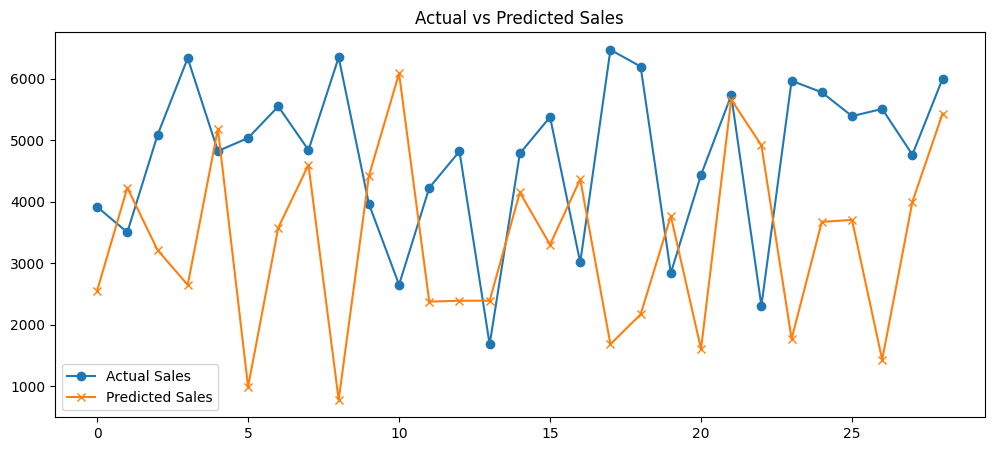

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual Sales", marker="o")
plt.plot(y_pred, label="Predicted Sales", marker="x")
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()



#Forecast & Save Everything

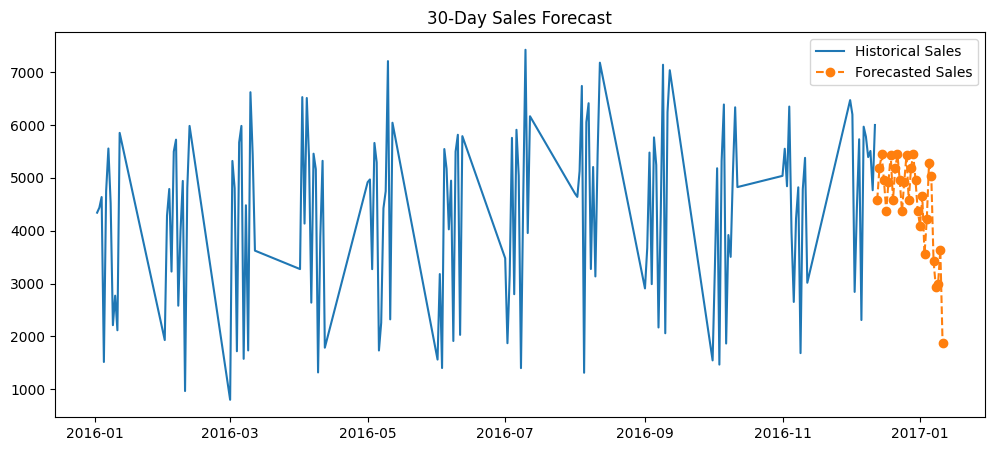

In [16]:
import datetime
import pandas as pd
import matplotlib.pyplot as plt

# Last date in dataset
last_date = daily_sales["Date"].max()

# Create future dates
future_dates = [last_date + datetime.timedelta(days=i) for i in range(1, 31)]
future_df = pd.DataFrame({"Date": future_dates})

# Same features as before
future_df["Day"] = future_df["Date"].dt.day
future_df["Month"] = future_df["Date"].dt.month
future_df["Year"] = future_df["Date"].dt.year
future_df["DayOfWeek"] = future_df["Date"].dt.dayofweek
future_df["IsWeekend"] = (future_df["DayOfWeek"] >= 5).astype(int)

# Predict future sales
future_df["Predicted_Sales"] = model.predict(future_df[["Day", "Month", "Year", "DayOfWeek", "IsWeekend"]])

# Plot
plt.figure(figsize=(12,5))
plt.plot(daily_sales["Date"], daily_sales["Sales_Amount"], label="Historical Sales")
plt.plot(future_df["Date"], future_df["Predicted_Sales"], label="Forecasted Sales", linestyle="--", marker="o")
plt.legend()
plt.title("30-Day Sales Forecast")
plt.show()


#Save Model for Reuse

In [17]:
import joblib

# Save XGBoost model
joblib.dump(model, "../models/xgb_sales_model.pkl")
print("✅ Model saved to ../models/xgb_sales_model.pkl")

# To load later:
# model = joblib.load("../models/xgb_sales_model.pkl")


✅ Model saved to ../models/xgb_sales_model.pkl


#Save Forecasted Results

In [18]:
future_df.to_csv("../results/future_sales_forecast.csv", index=False)
print("✅ Forecast saved to ../results/future_sales_forecast.csv")


✅ Forecast saved to ../results/future_sales_forecast.csv


#Save Plots for GitHub

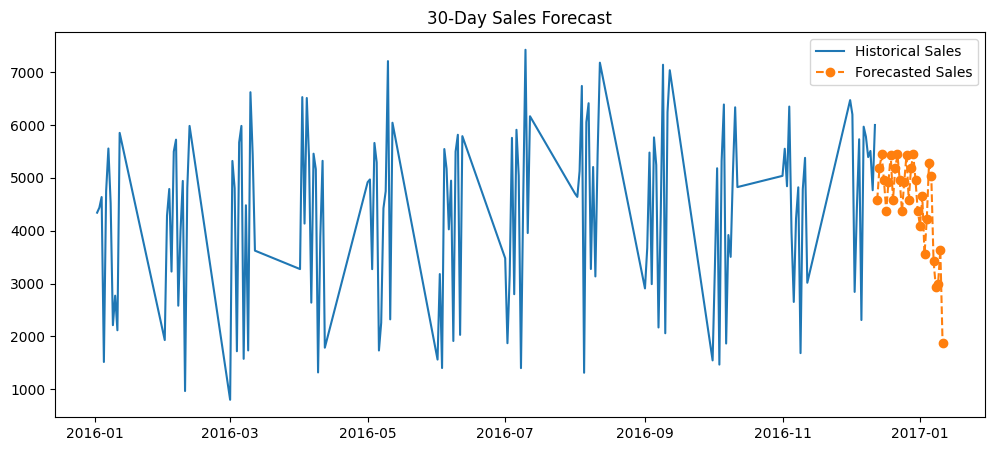

In [19]:
plt.figure(figsize=(12,5))
plt.plot(daily_sales["Date"], daily_sales["Sales_Amount"], label="Historical Sales")
plt.plot(future_df["Date"], future_df["Predicted_Sales"], label="Forecasted Sales", linestyle="--", marker="o")
plt.legend()
plt.title("30-Day Sales Forecast")
plt.savefig("../results/forecast_plot.png")  # save image
plt.show()
